# 03. Indicadores temporales y estacionales del oleaje

Este notebook analiza la variación mensual, estacional y anual de la altura significativa del oleaje, Hs.

El objetivo es transformar las series históricas horarias en indicadores temporales útiles para identificar periodos de mayor exposición marítima y apoyar una gestión portuaria basada en datos.

El análisis no se plantea como una comparación competitiva entre puertos. Las diferencias se interpretan considerando el tipo de boya, su localización y su exposición a las condiciones de mar abierto.



1. Cargar y comprobar el dataset principal de oleaje.
2. Crear variables de año, mes y estación.
3. Calcular indicadores mensuales de Hs.
4. Analizar la estacionalidad del oleaje.
5. Calcular indicadores y máximos anuales.
6. Interpretar los resultados desde la gestión portuaria.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid", context="notebook")

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [8]:
print("Archivos CSV disponibles:")

for archivo in os.listdir("/content"):
    if archivo.lower().endswith(".csv"):
        print("-", archivo)

Archivos CSV disponibles:
- dataset_principal_oleaje.csv


Se carga el archivo en el dataset principal de oelaje

In [10]:
RUTA_DATASET = Path(
    "/content/dataset_principal_oleaje.csv"
)

dataset_principal_oleaje = pd.read_csv(
    RUTA_DATASET,
    parse_dates=["fecha"]
)

print("Dataset cargado correctamente.")
print("Archivo:", RUTA_DATASET.name)
print(
    "Número de registros:",
    f"{len(dataset_principal_oleaje):,}"
)
print(
    "Número de columnas:",
    dataset_principal_oleaje.shape[1]
)

Dataset cargado correctamente.
Archivo: dataset_principal_oleaje.csv
Número de registros: 610,438
Número de columnas: 14


In [11]:
display(
    dataset_principal_oleaje.head()
)

,fecha,codigo_boya,nombre_boya,zona,tipo_red,tipo_boya,Hs_m,H1_3_m,Hmax_m,Tm02_s,Tp_s,dir_media_oleaje_grados,dir_pico_oleaje_grados,dispersion_pico_grados
0,2005-01-01 00:00:00,1103,Bilbao costera,Bilbao,Red costera,Costera,1.70,1.61,2.36,7.99,11.71,329.00,326.00,31.00
1,2005-01-01 01:00:00,1103,Bilbao costera,Bilbao,Red costera,Costera,2.03,1.89,2.94,8.44,11.70,328.00,326.00,40.00
2,2005-01-01 02:00:00,1103,Bilbao costera,Bilbao,Red costera,Costera,1.87,1.77,2.54,8.39,11.76,327.00,326.00,36.00
3,2005-01-01 03:00:00,1103,Bilbao costera,Bilbao,Red costera,Costera,2.04,1.92,2.72,8.71,12.48,329.00,333.00,36.00
4,2005-01-01 04:00:00,1103,Bilbao costera,Bilbao,Red costera,Costera,1.92,1.82,2.59,8.60,11.79,324.00,325.00,45.00


In [12]:
dataset_principal_oleaje.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 610438 entries, 0 to 610437
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   fecha                    610438 non-null  datetime64[ns]
 1   codigo_boya              610438 non-null  int64         
 2   nombre_boya              610438 non-null  object        
 3   zona                     610438 non-null  object        
 4   tipo_red                 610438 non-null  object        
 5   tipo_boya                610438 non-null  object        
 6   Hs_m                     610431 non-null  float64       
 7   H1_3_m                   291710 non-null  float64       
 8   Hmax_m                   603276 non-null  float64       
 9   Tm02_s                   610363 non-null  float64       
 10  Tp_s                     610431 non-null  float64       
 11  dir_media_oleaje_grados  601364 non-null  float64       
 12  dir_pico_oleaje_

Se crean carpetas de salida

In [13]:
FIGURES_DIR = Path("/content/figures")
TABLES_DIR = Path("/content/tables")

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TABLES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Carpeta de figuras:", FIGURES_DIR)
print("Carpeta de tablas:", TABLES_DIR)

Carpeta de figuras: /content/figures
Carpeta de tablas: /content/tables


VARIABLES TEMPORALES

In [15]:
datos_temporales = (
    dataset_principal_oleaje.copy()
)

print("Copia de trabajo creada.")
print(
    "Registros:",
    f"{len(datos_temporales):,}"
)

Copia de trabajo creada.
Registros: 610,438


Se crea año, mes, día y hora

In [16]:
datos_temporales["anio"] = (
    datos_temporales["fecha"].dt.year
)

datos_temporales["mes"] = (
    datos_temporales["fecha"].dt.month
)

datos_temporales["dia"] = (
    datos_temporales["fecha"].dt.day
)

datos_temporales["hora"] = (
    datos_temporales["fecha"].dt.hour
)

display(
    datos_temporales[
        [
            "fecha",
            "anio",
            "mes",
            "dia",
            "hora"
        ]
    ].head()
)

,fecha,anio,mes,dia,hora
0,2005-01-01 00:00:00,2005,1,1,0
1,2005-01-01 01:00:00,2005,1,1,1
2,2005-01-01 02:00:00,2005,1,1,2
3,2005-01-01 03:00:00,2005,1,1,3
4,2005-01-01 04:00:00,2005,1,1,4


Se crean los nombres de meses

In [18]:
nombres_meses = {
    1: "Ene",
    2: "Feb",
    3: "Mar",
    4: "Abr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Ago",
    9: "Sep",
    10: "Oct",
    11: "Nov",
    12: "Dic"
}

orden_meses = [
    "Ene",
    "Feb",
    "Mar",
    "Abr",
    "May",
    "Jun",
    "Jul",
    "Ago",
    "Sep",
    "Oct",
    "Nov",
    "Dic"
]

datos_temporales["nombre_mes"] = (
    datos_temporales["mes"].map(nombres_meses)
)

datos_temporales["nombre_mes"] = pd.Categorical(
    datos_temporales["nombre_mes"],
    categories=orden_meses,
    ordered=True
)

display(
    datos_temporales[
        [
            "fecha",
            "mes",
            "nombre_mes"
        ]
    ].head()
)

,fecha,mes,nombre_mes
0,2005-01-01 00:00:00,1,Ene
1,2005-01-01 01:00:00,1,Ene
2,2005-01-01 02:00:00,1,Ene
3,2005-01-01 03:00:00,1,Ene
4,2005-01-01 04:00:00,1,Ene


Se crean nombres de estaciones

In [20]:
def asignar_estacion(mes):

    if mes in [12, 1, 2]:
        return "Invierno"

    elif mes in [3, 4, 5]:
        return "Primavera"

    elif mes in [6, 7, 8]:
        return "Verano"

    else:
        return "Otoño"


In [21]:
datos_temporales["estacion"] = (
    datos_temporales["mes"]
    .apply(asignar_estacion)
)

orden_estaciones = [
    "Invierno",
    "Primavera",
    "Verano",
    "Otoño"
]

datos_temporales["estacion"] = pd.Categorical(
    datos_temporales["estacion"],
    categories=orden_estaciones,
    ordered=True
)

Comprobación de meses y estaciones

In [22]:
comprobacion_temporal = (
    datos_temporales[
        [
            "mes",
            "nombre_mes",
            "estacion"
        ]
    ]
    .drop_duplicates()
    .sort_values("mes")
    .reset_index(drop=True)
)

display(comprobacion_temporal)

,mes,nombre_mes,estacion
0,1,Ene,Invierno
1,2,Feb,Invierno
2,3,Mar,Primavera
3,4,Abr,Primavera
4,5,May,Primavera
5,6,Jun,Verano
6,7,Jul,Verano
7,8,Ago,Verano
8,9,Sep,Otoño
9,10,Oct,Otoño


Comprobación general

In [23]:
print("COMPROBACIÓN TEMPORAL")
print("-" * 45)

print(
    "Primer año:",
    datos_temporales["anio"].min()
)

print(
    "Último año:",
    datos_temporales["anio"].max()
)

print(
    "Meses:",
    datos_temporales["mes"].nunique()
)

print(
    "Estaciones:",
    datos_temporales["estacion"].nunique()
)

print(
    "Registros:",
    f"{len(datos_temporales):,}"
)

COMPROBACIÓN TEMPORAL
---------------------------------------------
Primer año: 2004
Último año: 2024
Meses: 12
Estaciones: 4
Registros: 610,438


INDICADORES MENSUALES

## 1. Indicadores mensuales de Hs

Los indicadores mensuales permiten identificar cómo varía la altura significativa de ola a lo largo del año.

Se calculan la media, mediana, desviación típica, percentiles 90, 95 y 99, y el máximo mensual de Hs para cada boya.

La agrupación se realiza utilizando conjuntamente todos los años disponibles. Por tanto, los resultados representan el comportamiento histórico general de

Cálculo de indicadores mensuales

In [24]:
tabla_hs_mensual = (
    datos_temporales
    .groupby(
        [
            "codigo_boya",
            "nombre_boya",
            "tipo_boya",
            "mes",
            "nombre_mes"
        ],
        observed=True,
        as_index=False
    )
    .agg(
        registros=("Hs_m", "count"),
        Hs_media_m=("Hs_m", "mean"),
        Hs_mediana_m=("Hs_m", "median"),
        Hs_desviacion_m=("Hs_m", "std"),
        Hs_p90_m=("Hs_m", lambda x: x.quantile(0.90)),
        Hs_p95_m=("Hs_m", lambda x: x.quantile(0.95)),
        Hs_p99_m=("Hs_m", lambda x: x.quantile(0.99)),
        Hs_maxima_m=("Hs_m", "max")
    )
)

columnas_mensuales = [
    "Hs_media_m",
    "Hs_mediana_m",
    "Hs_desviacion_m",
    "Hs_p90_m",
    "Hs_p95_m",
    "Hs_p99_m",
    "Hs_maxima_m"
]

tabla_hs_mensual[columnas_mensuales] = (
    tabla_hs_mensual[columnas_mensuales]
    .round(2)
)

tabla_hs_mensual = (
    tabla_hs_mensual
    .sort_values(["codigo_boya", "mes"])
    .reset_index(drop=True)
)

display(tabla_hs_mensual.head(12))

,codigo_boya,nombre_boya,tipo_boya,mes,nombre_mes,registros,Hs_media_m,Hs_mediana_m,Hs_desviacion_m,Hs_p90_m,Hs_p95_m,Hs_p99_m,Hs_maxima_m
0,1103,Bilbao costera,Costera,1,Ene,9698,1.91,1.72,1.03,3.41,3.99,4.88,7.00
1,1103,Bilbao costera,Costera,2,Feb,10207,1.84,1.64,0.96,3.11,3.68,4.78,6.19
2,1103,Bilbao costera,Costera,3,Mar,11974,1.60,1.40,0.88,2.76,3.24,4.40,8.19
3,1103,Bilbao costera,Costera,4,Abr,11481,1.26,1.12,0.65,2.08,2.53,3.45,5.91
4,1103,Bilbao costera,Costera,5,May,12068,1.15,1.03,0.60,1.92,2.28,3.14,5.77
5,1103,Bilbao costera,Costera,6,Jun,11976,1.00,0.92,0.46,1.60,1.89,2.60,4.13
6,1103,Bilbao costera,Costera,7,Jul,12360,1.02,0.93,0.43,1.57,1.84,2.47,3.53
7,1103,Bilbao costera,Costera,8,Ago,12822,1.09,0.96,0.50,1.76,2.04,2.71,4.28
8,1103,Bilbao costera,Costera,9,Sep,12203,1.24,1.15,0.59,2.01,2.40,3.04,5.58
9,1103,Bilbao costera,Costera,10,Oct,12683,1.34,1.16,0.72,2.34,2.81,3.62,5.11


In [25]:
ruta_hs_mensual = (
    TABLES_DIR / "tabla_hs_mensual.csv"
)

tabla_hs_mensual.to_csv(
    ruta_hs_mensual,
    index=False,
    encoding="utf-8-sig"
)

print("Tabla guardada:")
print(ruta_hs_mensual)

Tabla guardada:
/content/tables/tabla_hs_mensual.csv


GRÁFICO HS MENSUAL

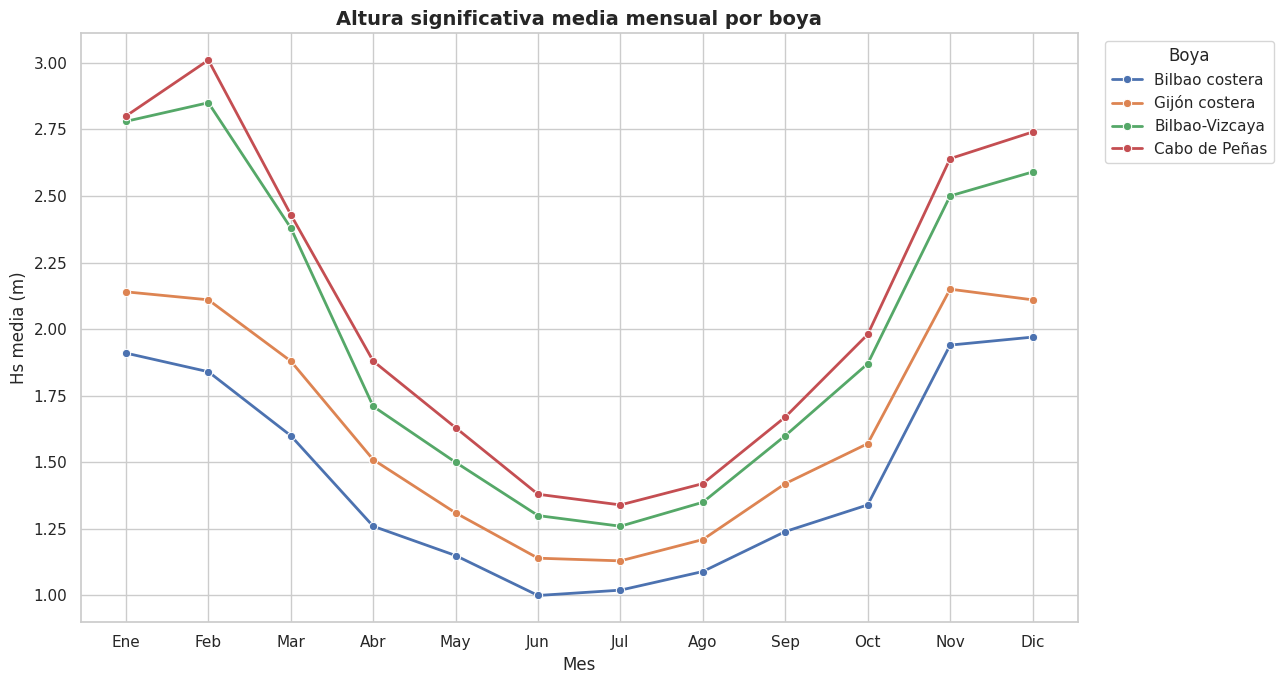

Figura guardada:
/content/figures/media_mensual_hs_por_boya.png


In [26]:
plt.figure(figsize=(13, 7))

sns.lineplot(
    data=tabla_hs_mensual,
    x="nombre_mes",
    y="Hs_media_m",
    hue="nombre_boya",
    hue_order=[
        "Bilbao costera",
        "Gijón costera",
        "Bilbao-Vizcaya",
        "Cabo de Peñas"
    ],
    marker="o",
    linewidth=2
)

plt.title(
    "Altura significativa media mensual por boya",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Mes")
plt.ylabel("Hs media (m)")
plt.legend(
    title="Boya",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

ruta_media_mensual = (
    FIGURES_DIR /
    "media_mensual_hs_por_boya.png"
)

plt.savefig(
    ruta_media_mensual,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figura guardada:")
print(ruta_media_mensual)

GRÁFICO P95 MENSUAL

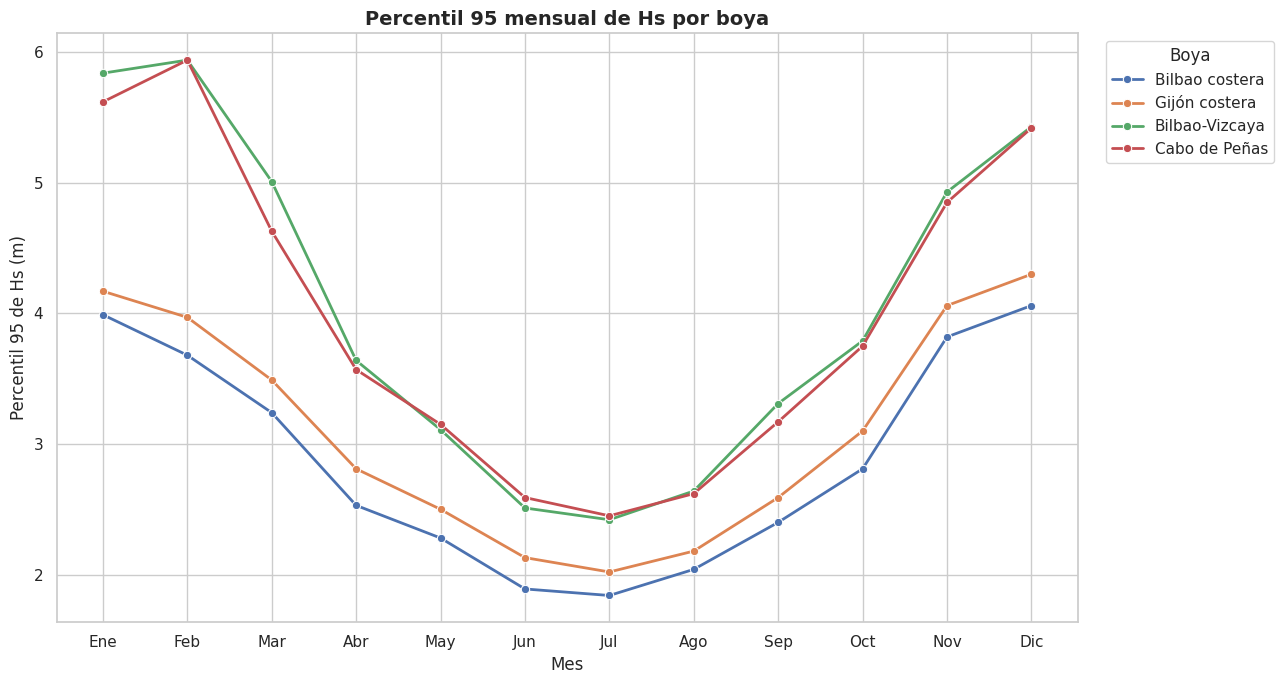

Figura guardada:
/content/figures/percentil95_mensual_hs_por_boya.png


In [27]:
plt.figure(figsize=(13, 7))

sns.lineplot(
    data=tabla_hs_mensual,
    x="nombre_mes",
    y="Hs_p95_m",
    hue="nombre_boya",
    hue_order=[
        "Bilbao costera",
        "Gijón costera",
        "Bilbao-Vizcaya",
        "Cabo de Peñas"
    ],
    marker="o",
    linewidth=2
)

plt.title(
    "Percentil 95 mensual de Hs por boya",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Mes")
plt.ylabel("Percentil 95 de Hs (m)")
plt.legend(
    title="Boya",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

ruta_p95_mensual = (
    FIGURES_DIR /
    "percentil95_mensual_hs_por_boya.png"
)

plt.savefig(
    ruta_p95_mensual,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figura guardada:")
print(ruta_p95_mensual)

Boxplot mensual de HS

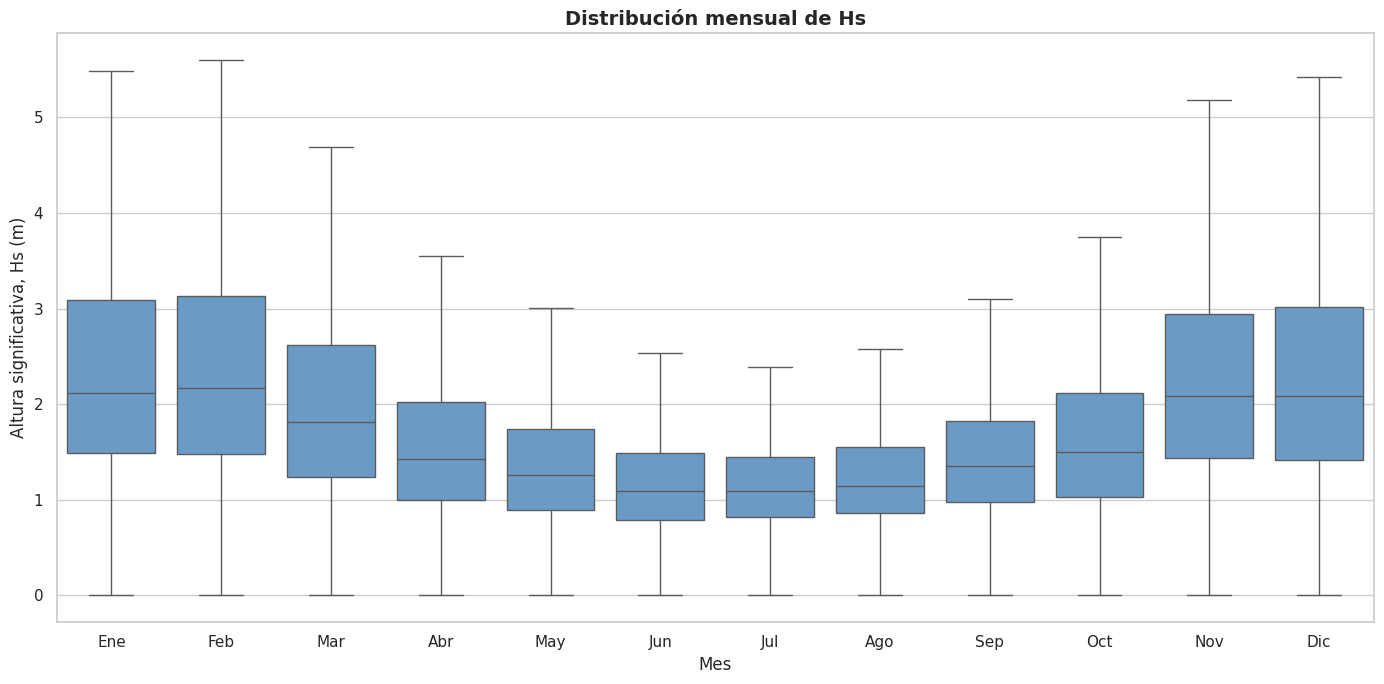

Figura guardada:
/content/figures/boxplot_mensual_hs.png


In [28]:
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=datos_temporales,
    x="nombre_mes",
    y="Hs_m",
    order=orden_meses,
    showfliers=False,
    color="#5B9BD5"
)

plt.title(
    "Distribución mensual de Hs",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Mes")
plt.ylabel("Altura significativa, Hs (m)")

plt.tight_layout()

ruta_boxplot_mensual = (
    FIGURES_DIR / "boxplot_mensual_hs.png"
)

plt.savefig(
    ruta_boxplot_mensual,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figura guardada:")
print(ruta_boxplot_mensual)

Se identifican los meses de mayor HS media

In [29]:
meses_mayor_hs = (
    tabla_hs_mensual
    .loc[
        tabla_hs_mensual
        .groupby("codigo_boya")["Hs_media_m"]
        .idxmax()
    ]
    [
        [
            "codigo_boya",
            "nombre_boya",
            "tipo_boya",
            "nombre_mes",
            "Hs_media_m",
            "Hs_p95_m",
            "Hs_maxima_m"
        ]
    ]
    .sort_values("codigo_boya")
    .reset_index(drop=True)
)

display(meses_mayor_hs)

,codigo_boya,nombre_boya,tipo_boya,nombre_mes,Hs_media_m,Hs_p95_m,Hs_maxima_m
0,1103,Bilbao costera,Costera,Dic,1.97,4.06,8.37
1,1117,Gijón costera,Costera,Nov,2.15,4.06,7.94
2,2136,Bilbao-Vizcaya,Exterior,Feb,2.85,5.94,11.13
3,2242,Cabo de Peñas,Exterior,Feb,3.01,5.94,11.28


In [30]:
meses_mayor_hs = (
    tabla_hs_mensual
    .loc[
        tabla_hs_mensual
        .groupby("codigo_boya")["Hs_media_m"]
        .idxmax()
    ]
    [
        [
            "codigo_boya",
            "nombre_boya",
            "tipo_boya",
            "nombre_mes",
            "Hs_media_m",
            "Hs_p95_m",
            "Hs_maxima_m"
        ]
    ]
    .sort_values("codigo_boya")
    .reset_index(drop=True)
)

display(meses_mayor_hs)

,codigo_boya,nombre_boya,tipo_boya,nombre_mes,Hs_media_m,Hs_p95_m,Hs_maxima_m
0,1103,Bilbao costera,Costera,Dic,1.97,4.06,8.37
1,1117,Gijón costera,Costera,Nov,2.15,4.06,7.94
2,2136,Bilbao-Vizcaya,Exterior,Feb,2.85,5.94,11.13
3,2242,Cabo de Peñas,Exterior,Feb,3.01,5.94,11.28


INDICADORES ESTACIONALES

## 2. Indicadores estacionales

La agrupación por estaciones permite resumir el comportamiento anual del oleaje y comprobar si los valores más elevados se concentran en determinados periodos.

Se emplean las estaciones meteorológicas habituales:

- invierno: diciembre, enero y febrero;
- primavera: marzo, abril y mayo;
- verano: junio, julio y agosto;
- otoño: septiembre, octubre y noviembre.

In [31]:
tabla_hs_estacional = (
    datos_temporales
    .groupby(
        [
            "codigo_boya",
            "nombre_boya",
            "tipo_boya",
            "estacion"
        ],
        observed=True,
        as_index=False
    )
    .agg(
        registros=("Hs_m", "count"),
        Hs_media_m=("Hs_m", "mean"),
        Hs_mediana_m=("Hs_m", "median"),
        Hs_p90_m=("Hs_m", lambda x: x.quantile(0.90)),
        Hs_p95_m=("Hs_m", lambda x: x.quantile(0.95)),
        Hs_p99_m=("Hs_m", lambda x: x.quantile(0.99)),
        Hs_maxima_m=("Hs_m", "max")
    )
)

columnas_estacionales = [
    "Hs_media_m",
    "Hs_mediana_m",
    "Hs_p90_m",
    "Hs_p95_m",
    "Hs_p99_m",
    "Hs_maxima_m"
]

tabla_hs_estacional[columnas_estacionales] = (
    tabla_hs_estacional[columnas_estacionales]
    .round(2)
)

display(tabla_hs_estacional)

,codigo_boya,nombre_boya,tipo_boya,estacion,registros,Hs_media_m,Hs_mediana_m,Hs_p90_m,Hs_p95_m,Hs_p99_m,Hs_maxima_m
0,1103,Bilbao costera,Costera,Invierno,30889,1.91,1.72,3.31,3.90,5.06,8.37
1,1103,Bilbao costera,Costera,Primavera,35523,1.34,1.16,2.31,2.79,3.83,8.19
2,1103,Bilbao costera,Costera,Verano,37158,1.03,0.93,1.65,1.93,2.60,4.28
3,1103,Bilbao costera,Costera,Otoño,37418,1.51,1.31,2.66,3.18,4.29,7.02
4,1117,Gijón costera,Costera,Invierno,35009,2.12,1.91,3.50,4.12,5.33,8.98
5,1117,Gijón costera,Costera,Primavera,37471,1.56,1.39,2.60,3.04,3.95,7.26
6,1117,Gijón costera,Costera,Verano,37950,1.16,1.07,1.81,2.11,2.70,5.10
7,1117,Gijón costera,Costera,Otoño,40289,1.70,1.52,2.86,3.39,4.60,7.94
8,2136,Bilbao-Vizcaya,Exterior,Invierno,38460,2.73,2.40,4.80,5.73,7.45,13.72
9,2136,Bilbao-Vizcaya,Exterior,Primavera,38960,1.85,1.55,3.33,4.09,5.68,11.55


In [32]:
tabla_hs_estacional = (
    datos_temporales
    .groupby(
        [
            "codigo_boya",
            "nombre_boya",
            "tipo_boya",
            "estacion"
        ],
        observed=True,
        as_index=False
    )
    .agg(
        registros=("Hs_m", "count"),
        Hs_media_m=("Hs_m", "mean"),
        Hs_mediana_m=("Hs_m", "median"),
        Hs_p90_m=("Hs_m", lambda x: x.quantile(0.90)),
        Hs_p95_m=("Hs_m", lambda x: x.quantile(0.95)),
        Hs_p99_m=("Hs_m", lambda x: x.quantile(0.99)),
        Hs_maxima_m=("Hs_m", "max")
    )
)

columnas_estacionales = [
    "Hs_media_m",
    "Hs_mediana_m",
    "Hs_p90_m",
    "Hs_p95_m",
    "Hs_p99_m",
    "Hs_maxima_m"
]

tabla_hs_estacional[columnas_estacionales] = (
    tabla_hs_estacional[columnas_estacionales]
    .round(2)
)

display(tabla_hs_estacional)

,codigo_boya,nombre_boya,tipo_boya,estacion,registros,Hs_media_m,Hs_mediana_m,Hs_p90_m,Hs_p95_m,Hs_p99_m,Hs_maxima_m
0,1103,Bilbao costera,Costera,Invierno,30889,1.91,1.72,3.31,3.90,5.06,8.37
1,1103,Bilbao costera,Costera,Primavera,35523,1.34,1.16,2.31,2.79,3.83,8.19
2,1103,Bilbao costera,Costera,Verano,37158,1.03,0.93,1.65,1.93,2.60,4.28
3,1103,Bilbao costera,Costera,Otoño,37418,1.51,1.31,2.66,3.18,4.29,7.02
4,1117,Gijón costera,Costera,Invierno,35009,2.12,1.91,3.50,4.12,5.33,8.98
5,1117,Gijón costera,Costera,Primavera,37471,1.56,1.39,2.60,3.04,3.95,7.26
6,1117,Gijón costera,Costera,Verano,37950,1.16,1.07,1.81,2.11,2.70,5.10
7,1117,Gijón costera,Costera,Otoño,40289,1.70,1.52,2.86,3.39,4.60,7.94
8,2136,Bilbao-Vizcaya,Exterior,Invierno,38460,2.73,2.40,4.80,5.73,7.45,13.72
9,2136,Bilbao-Vizcaya,Exterior,Primavera,38960,1.85,1.55,3.33,4.09,5.68,11.55


GRAFICO ESTACIONAL

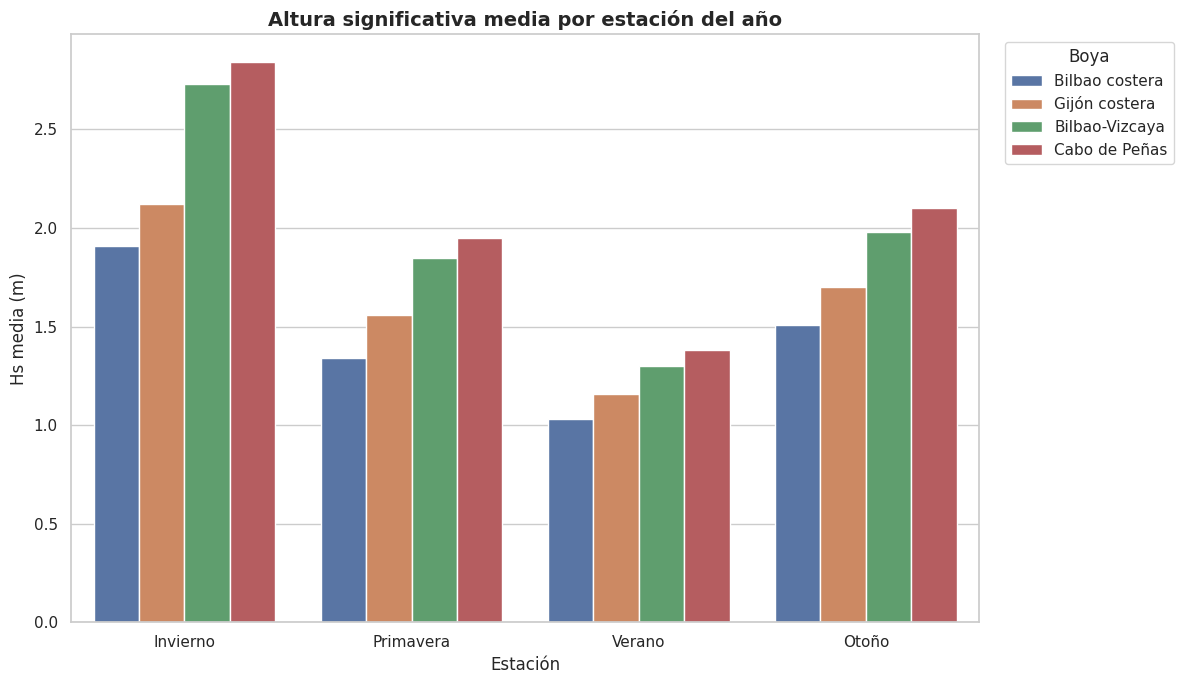

Figura guardada:
/content/figures/hs_media_por_estacion.png


In [33]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=tabla_hs_estacional,
    x="estacion",
    y="Hs_media_m",
    hue="nombre_boya",
    order=orden_estaciones
)

plt.title(
    "Altura significativa media por estación del año",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Estación")
plt.ylabel("Hs media (m)")
plt.legend(
    title="Boya",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

ruta_estacional = (
    FIGURES_DIR /
    "hs_media_por_estacion.png"
)

plt.savefig(
    ruta_estacional,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figura guardada:")
print(ruta_estacional)

INDICADORES ANUALES

Calculo de los indicadores anuales

In [34]:
tabla_hs_anual = (
    datos_temporales
    .groupby(
        [
            "codigo_boya",
            "nombre_boya",
            "tipo_boya",
            "anio"
        ],
        as_index=False
    )
    .agg(
        registros=("Hs_m", "count"),
        Hs_media_m=("Hs_m", "mean"),
        Hs_mediana_m=("Hs_m", "median"),
        Hs_p95_m=("Hs_m", lambda x: x.quantile(0.95)),
        Hs_p99_m=("Hs_m", lambda x: x.quantile(0.99)),
        Hs_maxima_m=("Hs_m", "max")
    )
)

columnas_anuales = [
    "Hs_media_m",
    "Hs_mediana_m",
    "Hs_p95_m",
    "Hs_p99_m",
    "Hs_maxima_m"
]

tabla_hs_anual[columnas_anuales] = (
    tabla_hs_anual[columnas_anuales]
    .round(2)
)

display(tabla_hs_anual.head())

,codigo_boya,nombre_boya,tipo_boya,anio,registros,Hs_media_m,Hs_mediana_m,Hs_p95_m,Hs_p99_m,Hs_maxima_m
0,1103,Bilbao costera,Costera,2005,7698,1.30,1.09,2.79,3.61,5.63
1,1103,Bilbao costera,Costera,2006,5691,1.22,1.06,2.62,3.91,5.28
2,1103,Bilbao costera,Costera,2007,6424,1.27,1.08,2.69,4.58,8.37
3,1103,Bilbao costera,Costera,2008,8538,1.56,1.31,3.25,4.46,8.19
4,1103,Bilbao costera,Costera,2009,7981,1.49,1.24,3.49,4.84,7.00


In [35]:
tabla_hs_anual = (
    datos_temporales
    .groupby(
        [
            "codigo_boya",
            "nombre_boya",
            "tipo_boya",
            "anio"
        ],
        as_index=False
    )
    .agg(
        registros=("Hs_m", "count"),
        Hs_media_m=("Hs_m", "mean"),
        Hs_mediana_m=("Hs_m", "median"),
        Hs_p95_m=("Hs_m", lambda x: x.quantile(0.95)),
        Hs_p99_m=("Hs_m", lambda x: x.quantile(0.99)),
        Hs_maxima_m=("Hs_m", "max")
    )
)

columnas_anuales = [
    "Hs_media_m",
    "Hs_mediana_m",
    "Hs_p95_m",
    "Hs_p99_m",
    "Hs_maxima_m"
]

tabla_hs_anual[columnas_anuales] = (
    tabla_hs_anual[columnas_anuales]
    .round(2)
)

display(tabla_hs_anual.head())

,codigo_boya,nombre_boya,tipo_boya,anio,registros,Hs_media_m,Hs_mediana_m,Hs_p95_m,Hs_p99_m,Hs_maxima_m
0,1103,Bilbao costera,Costera,2005,7698,1.30,1.09,2.79,3.61,5.63
1,1103,Bilbao costera,Costera,2006,5691,1.22,1.06,2.62,3.91,5.28
2,1103,Bilbao costera,Costera,2007,6424,1.27,1.08,2.69,4.58,8.37
3,1103,Bilbao costera,Costera,2008,8538,1.56,1.31,3.25,4.46,8.19
4,1103,Bilbao costera,Costera,2009,7981,1.49,1.24,3.49,4.84,7.00


Máximos anuales

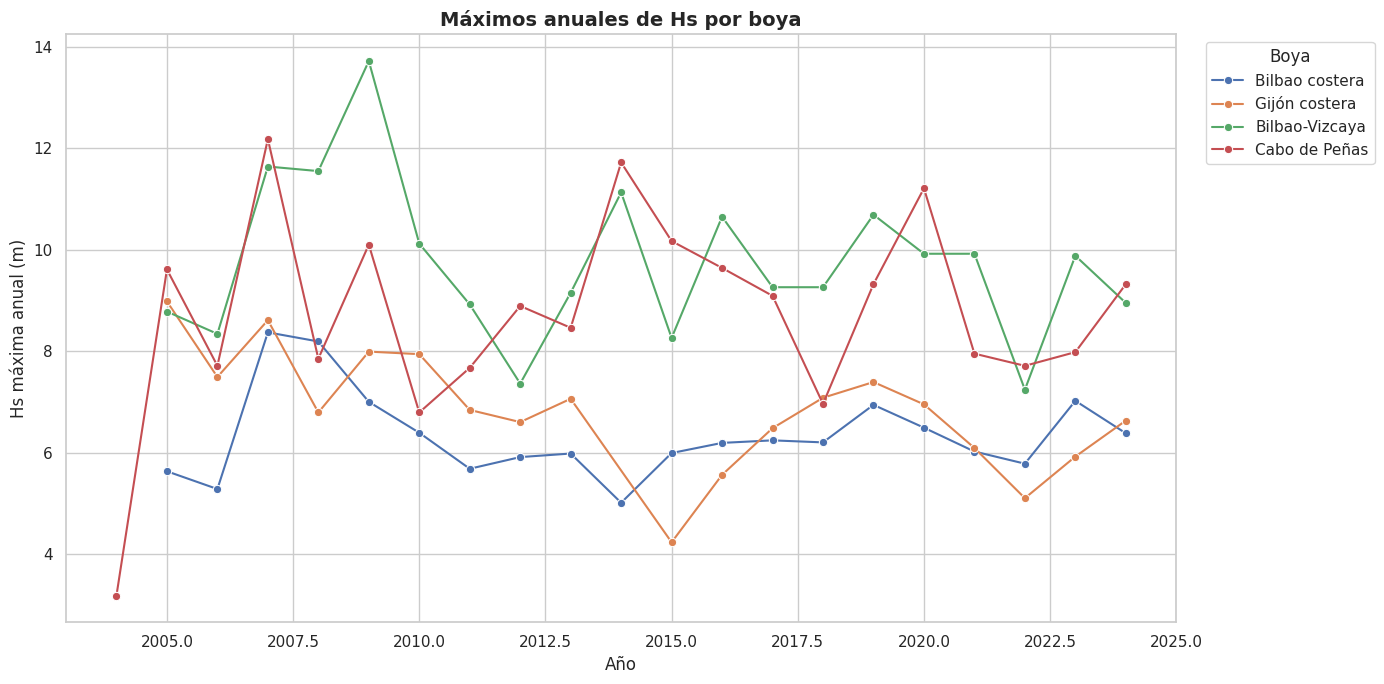

Figura guardada:
/content/figures/maximos_anuales_hs.png


In [36]:
plt.figure(figsize=(14, 7))

sns.lineplot(
    data=tabla_hs_anual,
    x="anio",
    y="Hs_maxima_m",
    hue="nombre_boya",
    marker="o",
    linewidth=1.5
)

plt.title(
    "Máximos anuales de Hs por boya",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Año")
plt.ylabel("Hs máxima anual (m)")
plt.legend(
    title="Boya",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

ruta_maximos_anuales = (
    FIGURES_DIR /
    "maximos_anuales_hs.png"
)

plt.savefig(
    ruta_maximos_anuales,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figura guardada:")
print(ruta_maximos_anuales)

## 3. Conclusiones del análisis temporal y estacional

El análisis temporal muestra que el oleaje presenta una estacionalidad clara. Los valores medios, los percentiles altos y los máximos tienden a aumentar durante los meses de otoño e invierno y a disminuir durante primavera y verano.

Este comportamiento se observa tanto en las boyas costeras como en las exteriores, aunque las estaciones exteriores mantienen valores más elevados debido a su mayor exposición a condiciones de mar abierto.

Los indicadores mensuales permiten identificar los periodos del año con una mayor frecuencia histórica de condiciones elevadas. Los indicadores estacionales condensan esta información y facilitan su interpretación desde la gestión portuaria.

La evolución anual muestra variabilidad entre años. Los máximos anuales pueden estar condicionados por episodios puntuales, por lo que deben interpretarse conjuntamente con la media anual y el percentil 95.

Estos resultados pueden apoyar la planificación de actividades sensibles, la programación de mantenimiento y la identificación de periodos en los que puede ser necesario reforzar el seguimiento de las condiciones marítimas.

Los indicadores obtenidos no se consideran límites oficiales de operatividad. Su finalidad es describir objetivamente el comportamiento histórico de las series y preparar el análisis de episodios potencialmente adversos.

Comprobación de tablas y figuras creadas

In [37]:
print("TABLAS GENERADAS")
print("-" * 45)

for archivo in sorted(os.listdir(TABLES_DIR)):
    print("-", archivo)

print("\nFIGURAS GENERADAS")
print("-" * 45)

for archivo in sorted(os.listdir(FIGURES_DIR)):
    print("-", archivo)

TABLAS GENERADAS
---------------------------------------------
- tabla_hs_mensual.csv

FIGURAS GENERADAS
---------------------------------------------
- boxplot_mensual_hs.png
- hs_media_por_estacion.png
- maximos_anuales_hs.png
- media_mensual_hs_por_boya.png
- percentil95_mensual_hs_por_boya.png


Se crea la carpeta zip archivos descarga

In [40]:
import shutil

shutil.make_archive(
    "/content/tablas_notebook_03",
    "zip",
    TABLES_DIR
)

shutil.make_archive(
    "/content/figuras_notebook_03",
    "zip",
    FIGURES_DIR
)

print("ZIP creados correctamente.")

ZIP creados correctamente.


Descarga resultados

In [41]:
from google.colab import files

files.download(
    "/content/tablas_notebook_03.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [42]:
files.download(
    "/content/figuras_notebook_03.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>